# Statistical factor model for the covariance (SVD/PCA)

Instead of the noisy $N\times N$ sample covariance, **factorize the returns matrix directly**: $\tilde R \approx B F$, where $\tilde R$ is the row-demeaned $N\times T$ return matrix, $B\in\mathbb{R}^{N\times k}$ are factor loadings and $F\in\mathbb{R}^{k\times T}$ are the factor return series. Both are learned from an SVD: $\tilde R = U\Sigma V^\top \Rightarrow B = U_k\Sigma_k,\ F = V_k^\top$.

Then reconstruct a denoised, full-rank covariance
$$\Sigma_{\text{fac}} = \tfrac{1}{T-1}BB^\top + \Psi,\qquad \Psi = \mathrm{diag}\bigl(\mathrm{var}(\tilde R - BF)\bigr),$$
low-rank (the $k$ signal factors) plus diagonal idiosyncratic noise. Truncating to $k\ll T$ drops the small singular values that Marchenko-Pastur says are pure noise. This is literally probabilistic PCA. We use $\Sigma_{\text{fac}}$ for minimum-variance and test it out-of-sample vs 1/N, risk parity, and raw-$\Sigma$ min-var.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from stonks import get_prices, to_returns

%matplotlib inline


## Parameters


In [2]:
TOP_N = 500
TRAIN_MONTHS = 3
TEST_MONTHS = 1
PERIOD = "2y"
K_RANGE = [1, 3, 5, 10, 20, 40]   # number of factors to try
torch.manual_seed(0)


## Fetch, split, row-demean


In [3]:
prices = get_prices(top_n=TOP_N, period=PERIOD, interval="1d", field="close")
last = pd.Timestamp(prices.columns[-1])
returns = to_returns(prices.loc[:, prices.columns >= last - pd.DateOffset(months=TRAIN_MONTHS + TEST_MONTHS)]).dropna()
test_start = last - pd.DateOffset(months=TEST_MONTHS)
train = returns.loc[:, returns.columns < test_start]
test  = returns.loc[:, returns.columns >= test_start]
N = returns.shape[0]
tr = train.to_numpy(dtype=float); te = test.to_numpy(dtype=float)
Tn = tr.shape[1]
Rtilde = tr - tr.mean(axis=1, keepdims=True)   # row-demeaned returns
print(f"N={N}  train={tr.shape}  test={te.shape}")


N=453  train=(453, 61)  test=(453, 24)


## Factorize $\tilde R$ via SVD

$\tilde R = U\Sigma V^\top$. The factor covariance for a given $k$ is $\Sigma_{\text{fac}} = \frac{1}{T-1}BB^\top + \Psi$ with $B = U_k\Sigma_k$ and $\Psi$ the residual variances.


In [4]:
U, S, Vt = np.linalg.svd(Rtilde, full_matrices=False)

def factor_sigma(k):
    B = U[:, :k] * S[:k]                # N x k  loadings (= U_k Sigma_k)
    F = Vt[:k, :]                       # k x T  factor returns
    resid = Rtilde - B @ F
    Psi = (resid ** 2).sum(axis=1) / (Tn - 1)   # per-stock residual variance
    return (B @ B.T) / (Tn - 1) + np.diag(Psi)

Sigma_raw = (Rtilde @ Rtilde.T) / (Tn - 1)
print(f"raw sample Sigma:  rank={np.linalg.matrix_rank(Sigma_raw):3d}  cond={np.linalg.cond(Sigma_raw):.1e}")
Sf5 = factor_sigma(5)
print(f"factor Sigma k=5:  rank={np.linalg.matrix_rank(Sf5):3d}  cond={np.linalg.cond(Sf5):.1e}  (full-rank, well-conditioned)")


raw sample Sigma:  rank= 60  cond=9.0e+19
factor Sigma k=5:  rank=453  cond=1.9e+03  (full-rank, well-conditioned)


## Sanity check — what is PC1?

Over long windows PC1 is usually 'the market' (nearly every stock loads the same sign). SVD signs are arbitrary, so we look at the **majority-sign fraction**.


PC1 majority-sign fraction: 0.58  (1.0 = perfect 'market' factor)


Text(0.5, 0, 'loading')

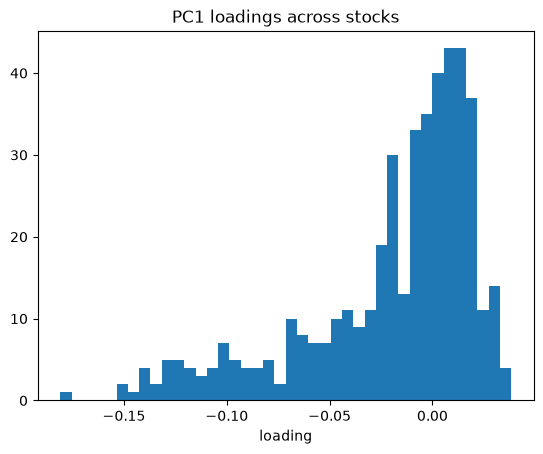

In [5]:
pc1 = U[:, 0]
maj = max((pc1 > 0).mean(), (pc1 < 0).mean())
print(f"PC1 majority-sign fraction: {maj:.2f}  (1.0 = perfect 'market' factor)")
plt.hist(pc1, bins=40)
plt.title("PC1 loadings across stocks"); plt.xlabel("loading")


## How many factors? (denoising)

The singular-value spectrum shows where signal turns into noise. We keep the top $k$ and drop the rest.


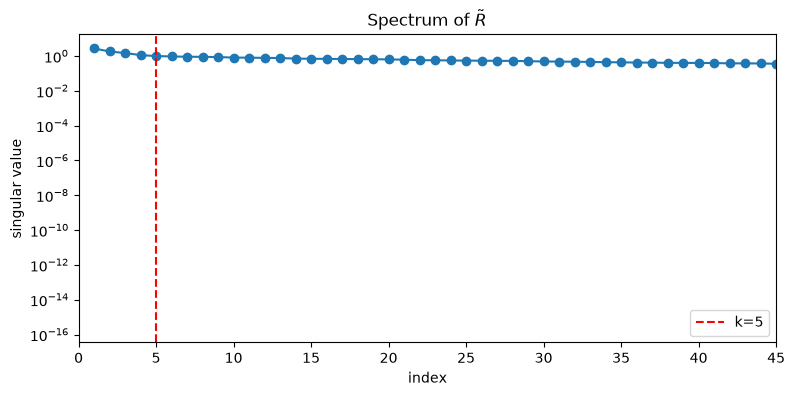

In [6]:
plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, len(S) + 1), S, "o-")
plt.axvline(5, color="r", ls="--", label="k=5")
plt.xlim(0, 45); plt.yscale("log")
plt.xlabel("index"); plt.ylabel("singular value"); plt.title("Spectrum of $\\tilde R$")
plt.legend()


## Minimum-variance on the factor covariance (out-of-sample)

Same train/test harness. For each $k$, build $\Sigma_{\text{fac}}$ on **train**, solve long-only min-variance, evaluate on **test**. Benchmarked against 1/N, risk parity, and raw-$\Sigma$ min-var.


In [7]:
def opt_minvar(Sigma):
    St = torch.tensor(Sigma, dtype=torch.float64)
    z = torch.zeros(N, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([z], lr=0.5)
    for _ in range(8000):
        opt.zero_grad(); w = torch.softmax(z, 0)
        (w @ St @ w).backward(); opt.step()
    return torch.softmax(z, 0).detach().numpy()

sigma = np.sqrt(np.diag(Sigma_raw))
strategies = {
    "1/N":              np.ones(N) / N,
    "risk parity":      (1 / sigma) / (1 / sigma).sum(),
    "minvar raw Sigma": opt_minvar(Sigma_raw),
}
for k in K_RANGE:
    strategies[f"minvar factor(k={k})"] = opt_minvar(factor_sigma(k))

def perf(w):
    rp = w @ te
    return np.prod(1 + rp) - 1, rp.std() * np.sqrt(252), rp.mean() / rp.std() * np.sqrt(252)

base = perf(strategies["1/N"])[2]
rows = []
for name, w in strategies.items():
    p, v, s = perf(w)
    rows.append({"strategy": name, "holdings": int((w > 1e-3).sum()),
                 "test_profit%": p * 100, "test_vol%": v * 100, "test_Sharpe": s,
                 "beats_1N_Sharpe": s > base})
results = pd.DataFrame(rows).sort_values("test_Sharpe", ascending=False).reset_index(drop=True)
results


,strategy,holdings,test_profit%,test_vol%,test_Sharpe,beats_1N_Sharpe
0,minvar factor(k=3),273,4.155714,6.276355,6.848822,True
1,minvar factor(k=5),260,4.409743,6.829011,6.675038,True
2,minvar factor(k=10),122,3.792348,6.840032,5.752516,True
3,risk parity,408,4.064722,9.071781,4.660658,True
4,minvar factor(k=1),306,3.540240,8.308610,4.441213,True
5,minvar factor(k=20),96,2.870329,7.228863,4.149091,True
6,1/N,453,4.420647,14.124350,3.288957,False
7,minvar factor(k=40),62,1.714589,8.854276,2.061095,False
8,minvar raw Sigma,40,1.910569,10.094669,2.019831,False


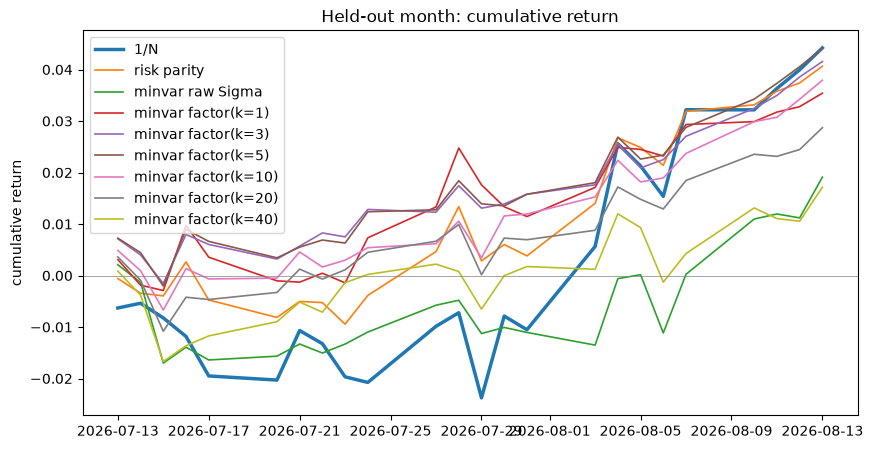

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, w in strategies.items():
    ax.plot(test.columns, np.cumprod(1 + w @ te) - 1,
            lw=2.5 if name == "1/N" else 1.2, label=name)
ax.axhline(0, color="gray", lw=0.5)
ax.set_ylabel("cumulative return"); ax.set_title("Held-out month: cumulative return")
ax.legend()


### Takeaway

- **Factorizing $\tilde R$ and building $\Sigma_{\text{fac}} = \tfrac{1}{T-1}BB^\top + \Psi$ denoises the covariance.** It's full-rank and well-conditioned (vs the rank-$(T{-}1)$, cond-$10^{20}$ sample $\Sigma$), and the resulting min-variance book beats raw-$\Sigma$ min-var, 1/N, and risk parity on risk-adjusted return.
- **$k$ is a denoising knob.** A few factors ($k\approx3\!\!-\!\!5$) capture the signal and give the best OOS Sharpe; too many ($k\to T$) re-absorbs Marchenko-Pastur noise and it degrades back toward raw $\Sigma$.
- **PC1 isn't always 'the market'.** Over this short window the majority-sign fraction was only ~0.58, so PC1 is more of a style/sector tilt than a clean broad-market factor — longer windows recover the usual all-positive market PC.
- This is the principled version of everything before: instead of estimating $O(N^2)$ noisy covariance entries, learn a few factors (probabilistic PCA) and treat the rest as idiosyncratic noise.
